---
title: Stability of the linear feedback control system
jupyter:
  jupytext:
    cell_metadata_filter: '-all'
    formats: ipynb,md,qmd
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.18.1
  kernelspec:
    display_name: Python 3 (ipykernel)
    language: python
    name: python3
---

In [1]:
import numpy as np
import control as ct
import sympy as sp
import matplotlib.pyplot as plt

# Introduction 
The stability of closed-loop feedback systems is crucial in control system design. A stable system should produce a bounded output for any bounded input, a principle known as bounded-input, bounded-output (BIBO) stability. This stability relates to the roots of the characteristic equation of the system's transfer function and the eigenvalues of the system transition matrix in state-variable format. 

The Routh–Hurwitz method is a valuable tool for assessing stability, allowing us to identify the number of roots in the right half-plane without calculating their exact values. This aids in designing parameters to achieve closed-loop stability. 

The performance of a feedback system is determined by the position of the roots of its characteristic equation in the s-plane. A root locus plot visually represents how these roots move as a single parameter changes, making it a crucial tool for designing and analyzing feedback control systems. We will discuss techniques for sketching root locus plots and the advantages of using computer-generated versions. These methods enable precise adjustments to the closed-loop feedback system's response when multiple parameters are varied. Finally, we will introduce the PID controller as a practical control framework.

# Desired outcomes
Upon completion of this section, we aim that you should be able to:

+  Explain the concept of stability of dynamic systems.

+ Describe the key concept of absolute and relative stability.

+ Explain BIBO stability.

+ Describe the relationship of the s-plane pole locations and the eigenvalue locations to system stability.

+ Construct a Routh array and employ Routh-Hurwitz stability criterion to determine system stability.

+ Describe the powerful concept of the root locus and its role in control system design.

+ Create a root locus plot by sketching or using computers.

+ Identify the PID controller as a key element of many feedback systems.

+ Explain the role of root locus plots in parameter design and system sensitivity analysis.

+ Design controllers to meet desired specifications using root locus methods.

# Concept of stability
Stability is essential in designing and analyzing feedback control systems. An unstable closed-loop feedback system offers little practical value, so all our control designs must ensure closed-loop stability. 

Many physical systems are inherently open-loop unstable, and some, like modern fighter aircraft, are intentionally designed this way. Without active feedback control, these aircraft cannot fly. Engineers implement active control to stabilize these systems, allowing for effective management of factors like transient performance. 

Feedback is used to stabilize both unstable and stable systems, enabling adjustments to meet design specifications such as steady-state tracking errors, percent overshoot, settling time, and time to peak.

A closed-loop feedback system can be classified as stable or unstable, a concept known as absolute stability. When a system is stable, we can assess its degree of stability, referred to as relative stability. 

Early aircraft designers recognized that greater stability made an aircraft harder to maneuver. Conversely, modern acrobatic aircraft are intentionally less stable, allowing for quicker turns. 

To determine absolute stability, we check that all poles of the transfer function or eigenvalues of the system transition matrix A lie in the left half of the s-plane. Once confirmed, we can analyze relative stability by examining their relative positions.

+ **Definition 1:**

> ==A stable system is a dynamic system with bounded response to a bounded input.
> A linear system is stable if and only if the absolute value of its impulse response $h_{cl}(t)$, integrated over an infinite range, is finite. 
$$
\int_{-\infty}^{+\infty}\vert h_{cl}(t)\vert dt <\infty
$$

In terms of linear systems, we recognize that the stability requirement may be defined in terms of the location of the poles of the closed-loop transfer function. A closed-loop system transfer function can be written as:

$$
H_{cl}(s)=\frac{N(s)}{D(s)}=K \frac{\prod\limits_{i=1}^{M}(s+z_{i})}{\prod\limits_{k=1}^{Q}(s+\sigma_{k})\prod\limits_{l=1}^{R}(s²+2\alpha_{l}s+\alpha_{l}²+\omega_{l}²)}
$$
The characteristic equation of this system is:
$$
D(s)=0\Rightarrow \exists\; r_{i}\in\mathbb{C}\;\vert\;D(r_{i})=0
$$
The output of the system in response to impulse input is given by:
$$
y(t) = h_{cl}(t)= \sum\limits_{k=1}^{Q}A_{k}e^{-\sigma_{k}t}+\sum\limits_{l=1}^{R} \frac{B_{l}}{\omega_{l}}e^{-\alpha_{l}t}\sin \left(\omega_{l}t+\theta_{l})\right) 
$$

For the output $y(t)$ to be bounded, the poles of the system must be located in the left half of the s-plane. Therefore, *a necessary and sufficient condition for a feedback system to be asymptotically stable is that all the poles of its transfer function have negative real parts. Conversely, a feedback system will be unstable if there is at least one pole whose real part is not negative. If some poles of the feedback system are located on the imaginary axis of the s-plane, then the system is considered to be marginally stable.*

***Example:***
Consider the feedback closed-loop system described by this transfer function:
$$
H(s) = \frac{1}{(s+10)(s²+16)}
$$

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              1
  -------------------------
  s^3 + 10 s^2 + 16 s + 160


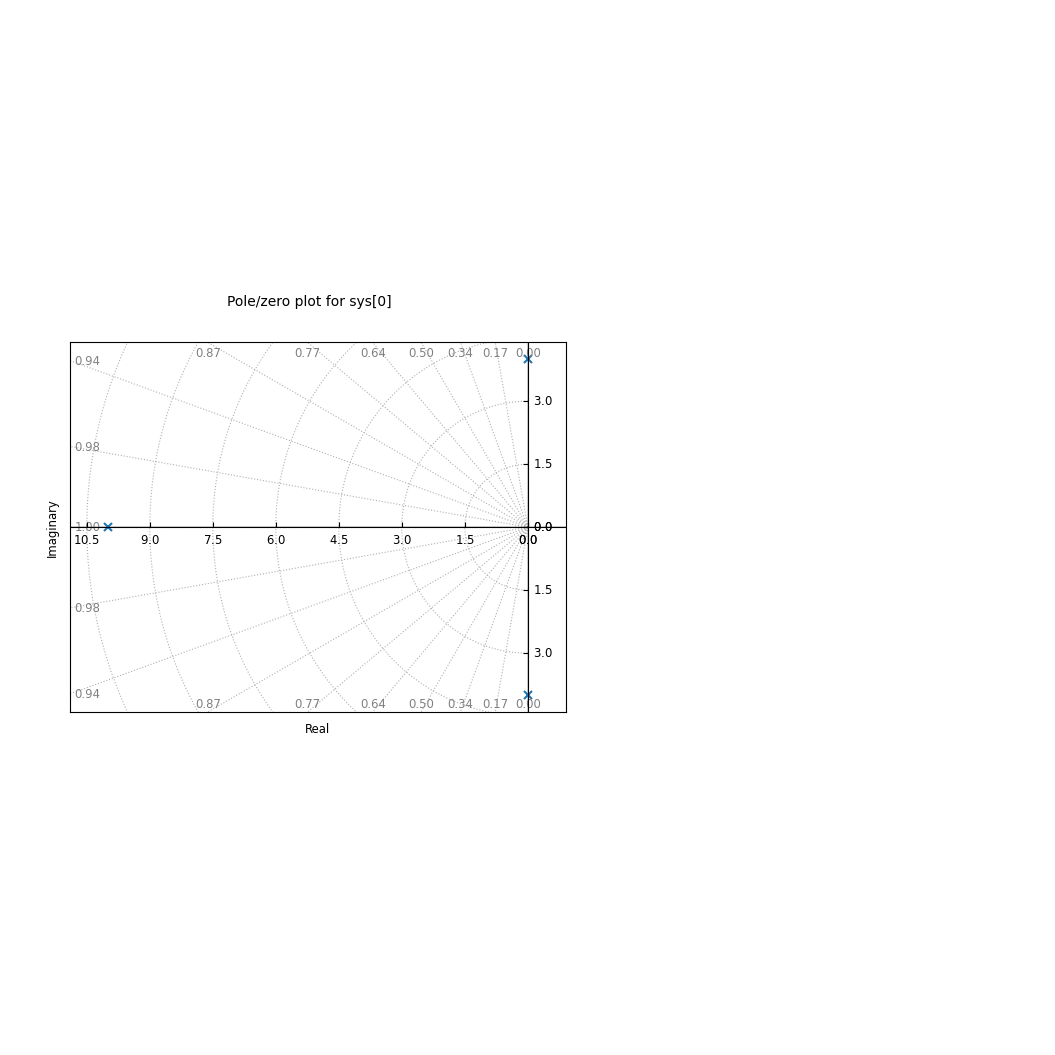

In [2]:
# run-python
sys = ct.zpk([],[-10,4j,-4j],1)
print(sys)
pzmap = ct.pole_zero_map(sys)
pzmap.plot(grid=True)
plt.show()

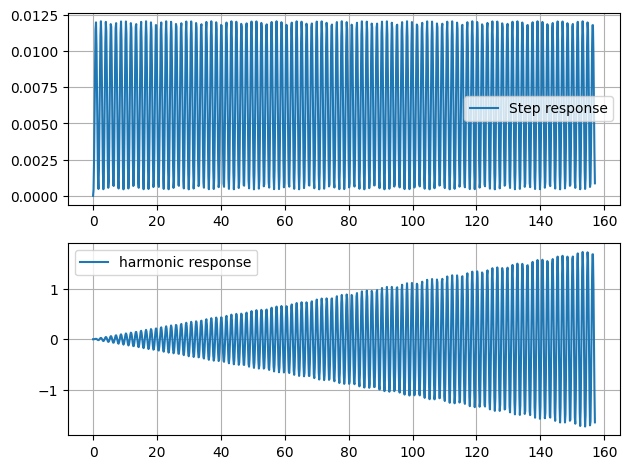

In [3]:
# run-python
sys = ct.zpk([],[-10,4j,-4j],1)
w0 = 4
pi = np.pi
tt = np.linspace(0,200*pi/w0,1024)
_, y1 = sys.step_response(timepts=tt)
_, y2 = sys.forced_response(timepts=tt,inputs=np.sin(w0*tt))
fig = plt.figure()
ax = fig.add_subplot(211,)
ax.plot(tt,y1, label='Step response')
ax.legend()
ax.grid()
ax = fig.add_subplot(2,1,2)
ax.plot(tt,y2, label='harmonic response')
ax.legend()
ax.grid()
fig.tight_layout()
plt.show()
#

# THE ROUTH–HURWITZ STABILITY CRITERION
The Routh–Hurwitz stability method provides an answer to the question of stability by considering the characteristic equation of the system. The characteristic equation is written as:
$$
D(s) = a_{n}s^{n}+a_{n-1}s^{n-1}+\cdots +a_{1}s+a_{0}=0
$$
To ascertain the stability of the system, it is necessary to determine whether any one
of the roots of $D(s)$ lies in the right half of the s-plane. The characteristic equation is rewritten in factored form, we have:
$$
a_{n}(s-r_{1})(s-r_{2})\times\dots\times(s-r_{n}) = 0
$$
Multiplying the factors together, we find that:
$$
\begin{aligned}
D(s) &= a_{n}s^{n} - a_{n}\sum\limits_{i=1}^{n}r_{i}\;s^{n-1}\\
&+ a_{n} (r_{1}r_{2}+r_{2}r_{3}+r_{1}r_{3}+\dots)s^{n-2}\\
&- a_{n}(r_{1}r_{2}r_{3}+r_{1}r_{2}r_{4}+\dots)s^{n-3}\\
&\vdots\\
&+ a_{n }(-1)^{n} \prod\limits_{i=1}^{n}r_{i}=0
\end{aligned}
$$
Examining the above equation, we note that all the coefficients of the polynomial will
have the same sign if all the roots are in the left-hand s-plane. These requirement are necessary but not sufficient. That is, we immediately know the system is unstable if this condition not satisfied; yet if they are satisfied, we must proceed further to ascertain the stability of the system.

***Example***
Consider the characteristic equation defined by:
$$D(s)=(s+2)(s²-s+4) = s³+s²+2s+8$$
All coefficients of the characteristic polynomial are positive, still the system is unstable.

In [4]:
# run-python
from sympy.abc import s
D = s**3+s**2+2*s+8
for r in sp.solve(D,s,Dict=True):
    display(r,end=', ')

-2

1/2 - sqrt(15)*I/2

1/2 + sqrt(15)*I/2

The Routh–Hurwitz criterion is a necessary and sufficient criterion for the stability of linear systems. The Routh–Hurwitz criterion is based on ordering the coefficients of the characteristic equation:

$$
D(s) = a_{n} s^{n}+a_{n-1}s^{n-1}+a_{n-2}s^{n-2}+\dots+a_{1}s+a_{0}
$$ into array as follow:

$$
\begin{array}{c|cccc}
s^{n} & a_{n} & a_{n-2} & a_{n-4} & \cdots\\
s^{n-1} & a_{n-1} & a_{n-3} & a_{n-5} & \cdots\\
s^{n-2} & b_{n-1} & b_{n-3} & b_{n-5} & \cdots\\
s^{n-3} & c_{n-1} & c_{n-3} & c_{n-5} & \cdots\\
\vdots & \vdots & \vdots & \vdots &\\
1 & h_{n-1}
\end{array}
$$

where:
$$
\begin{aligned}
b_{n-1} &= {1 \over a_{n-1}}(a_{n-1}a_{n-2}-a_{n}a_{n-3}), b_{n-3}={1 \over a_{n-1}}(a_{n-1}a_{n-4}-a_{n}a_{n-5}),\dots\\ 
c_{n-1} &= {1 \over b_{n-1}}(b_{n-1}a_{n-3}-a_{n-1}b_{n-3}), c_{n-3}={1 \over b_{n-1}}(b_{n-1}a_{n-5}-a_{n-1}b_{n-5}),\dots\\
\vdots
\end{aligned}
$$

Once the Routh array is constructed then **the Routh–Hurwitz criterion states that the number of roots of $\mathbf{D(s)}$ with positive real parts is equal to the number of changes in sign of the first column of the Routh array. Four distinct cases or configurations of the first column array must be considered, and each must be treated separately and requires suitable modifications of the array calculation procedure: 
1. No element in the first column is zero; 
2. There is a zero in the first column, but some other elements of the row containing the zero in the first column are nonzero; 
3. There is a zero in the first column, and the other elements of the row containing the zero are also zero; and 
4. As in the third case, but with repeated roots on the jω -axis. 

To illustrate this method clearly, several examples will be presented for each case.

+ **Case 1: No element in the first column is zero**

  ***Example: 2nd-order system***
 $$
D(s) = a_{2}s²+a_{1}s+a_{0}  
$$
The Routh array is given by:
$$
\begin{array}{c|cc}
s^{2} & a_{2} & a_{0} \\
s & a_{1} & 0\\
1 & b_{1} & 0
\end{array}
$$ where:
$$
b_{1} = \frac{a_{1}a_{0}-a_{2}\times_{0}}{a_{1}}=a_{0}
$$
The 2nd_order system is asymptotically stable if all coefficients of the characteristic polynomial are positive.

TransferFunction(
array([1]),
array([1, 2, 3]),
outputs=1, inputs=1)

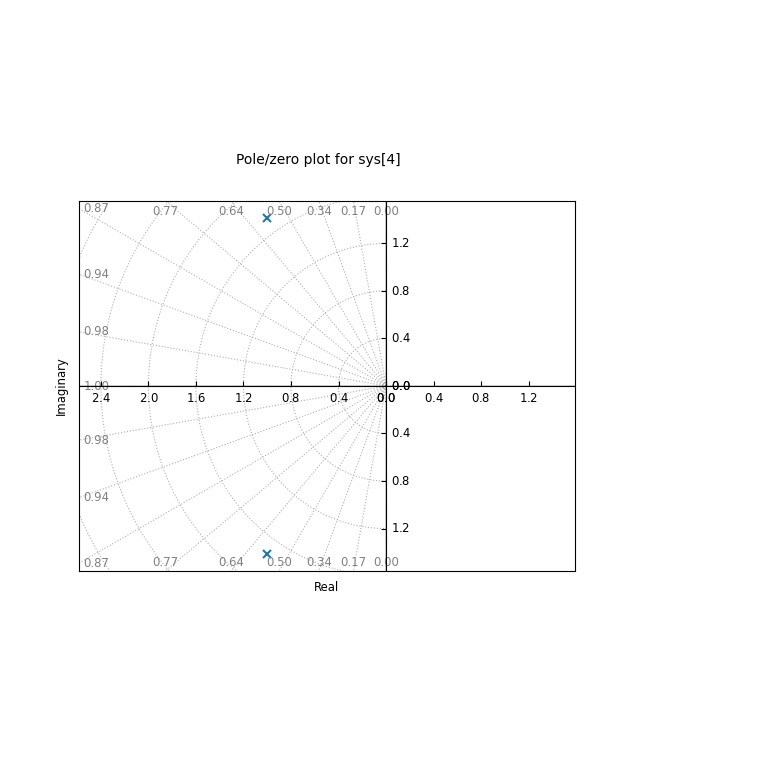

In [5]:
# run-python
sys = ct.tf([0,1],[1,2,3])
display(sys)
ct.pole_zero_map(sys).plot(grid=True)
plt.show()

***Example: 3rd_order system***

 $$
D(s) = a_{3}s³+a_{2}s²+a_{1}s+a_{0}  
$$
The Routh array is given by:
$$
\begin{array}{c|cc}
s^{3} & a_{3} & a_{1} \\
s² & a_{2} & a_{0}\\
s & b_{1} & 0\\
1 & c_{1} & 0
\end{array}
$$ where:
$$
\begin{cases}
b_{1} &= \frac{a_{2}a_{1}-a_{3}\times a_{0}}{a_{2}}\\
c_{1} &= \frac{b_{1}a_{0}-a_{0}\times 0}{b_{1}} = a_{0}\\
\end{cases}
$$

The 3rd-order system is asymptotically stable if all coefficients of the characteristic polynomial are positive and $a_{2}a_{1}>a_{3}a_{0}$.

In [ ]:
# run-python
den =[]
for i in range(4):
	den.append(float(input(f'Enter a{3-i}: ')))
print('done')
if den[2]*den[1]-den[3]*den[0]>0:
	sys = ct.tf([0,1],den)
	display(sys)
	ct.pole_zero_map(sys).plot(grid=True)
	plt.show()
else:
	print('Routh-Hurwitz criterion is not fullfield')
# 

# The relative stability of a feedback control systems
The Routh–Hurwitz criterion determines the absolute stability of a system by checking whether any roots of the characteristic equation lie in the right half of the s-plane. However, merely satisfying this criterion does not provide complete insight into the system's relative stability, which is essential for understanding the damping of each root. 

Relative stability refers to the comparison of the real parts of the roots, indicating their stability. For example, root $r_2$ may be more stable than roots $r_1$  and $r̂_{1}$, as shown in the figure below:
![](pics/diag77.svg)

It can also be defined in terms of relative damping coefficients $\zeta$  for complex root pairs, which affect the speed of response and overshoot. Assessing each root's relative stability is vital, as the location of closed-loop poles in the s-plane impacts overall system performance. Thus, exploring various methods for evaluating relative stability in the characteristic polynomial $Q(s)$ is necessary.

The stability of a system is determined by the positions of its characteristic equation roots. To analyze this using an s-plane, we can extend the Routh–Hurwitz criterion by shifting the vertical axis to $-σ_{1}$. This shift positions the roots $r_{1}$ and $\hat{r}_{1}$ on the new axis. The correct shift must be found through trial and error, allowing us to determine the real parts of the dominant roots $r_{1}$ and $\hat{r}_{1}$ without solving the fifth-order polynomial $Q(s)$.

***Example: Axis shift***

Consider the 3rd-order characteristic equation:
$$
Q(s) = s³+4s²+6s+4 = 0
$$

In [ ]:
# run-python
sigma = 0
s = ct.tf('s')
Q = (s+sigma)**3 +4*(s+sigma)**2 + 6*(s+sigma) + 4
ct.pole_zero_plot(1/Q,grid=True)
# 

Setting the shifted variable $z$ as $s = z+ \sigma$ we obtain:
$$
(z+\sigma)³ + 4(z+\sigma)²+6(z+\sigma)+4 = 0
$$
After expansion and simplification of the new characteristic equation we obtain:

$$
z^3 + (3σ + 4)z^2 + (3σ^2 + 8σ + 6)z + σ^3 + 4σ^2 + 6σ + 4 = 0 
$$
Let construct the Routh array for this characteristic equation:

$$
\begin{array}{c|ll}
z^{3} & 1 &3\sigma^{2}+8\sigma +6 \\
z² &3\sigma + 4  &σ^3 + 4σ^2 + 6σ + 4,\\
z & \frac{3σ^4 + 16σ^3 + 31σ^2 + 28σ + 10}{3σ + 4}
& 0\\
1 & σ^3 + 4σ^2 + 6σ + 4, & 0
\end{array}
$$

To maintain asymptotic stability for this system the shift parameter $\sigma \in\; ]-1,\infty[$  

In [ ]:
# run-python
import control as ct
s = ct.tf('s')
Q = s**3 + s**2 + s+ 1
ct.pole_zero_plot(1/Q,grid=True)